# Glass-Box PPO on an LLM — from scratch, every tensor visible

**Session 2 lab · companion to the PPO lecture.** No `PPOTrainer`. We build the loop by hand so each term from the slides is a printed tensor you can inspect and a dial you can turn.

### The cast (RLHF's four models, here three + a function)
| Role | In this lab |
|---|---|
| **Actor** (policy $\pi_\theta$) | GPT-2 + a value head — the thing we train |
| **Critic** (value $V_\phi$) | a linear value head on GPT-2's last hidden state |
| **Reference** $\pi_\text{ref}$ | a frozen copy of GPT-2 — the KL leash anchor |
| **Reward model** | a *trivial verifiable function* (count positive words) — no model to train |

Using a trivial reward keeps the spotlight on the **mechanics**: rollout → per-token reward shaping (terminal reward $-$ KL penalty) → GAE → importance ratio → clip → update.

### The three dials (everything from the lecture, made turnable)
- **clip $\epsilon$** — the trust region width in PPO-Clip → watch `clipfrac` and stability
- **GAE $\lambda$** — the bias/variance knob on advantages
- **KL coefficient $\beta$** — the leash to the reference. The headline experiment: sweep $\beta$ to watch **reward hacking / KL blow-up** (Goodhart, live).

> Runs on a single GPU in a few minutes with `gpt2` (124M). CPU works for tiny `batch_size`/`iters`. Swap the model name for a 0.5–1.5B model if you want — the loop is unchanged.

In [2]:
# If needed:  pip install torch transformers matplotlib
import copy, math, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from dataclasses import dataclass, field, replace
from transformers import AutoModelForCausalLM, AutoTokenizer

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
torch.manual_seed(0)
print("device:", device)

device: cuda


## 1 · The dials (config)

Edit this cell and re-run the training cell to feel each knob. The defaults are *starting points* — with a from-scratch loop on a trivial reward you may need to nudge `lr` / `iters` to see clean movement.

**Important, and itself a teaching point:** $\beta$ is only meaningful *relative to the reward scale*. Our reward is "number of positive words" (roughly 0–5), so a useful $\beta$ lives around 0.02–0.3. With a differently-scaled reward you'd rescale $\beta$ — exactly the scale-dependence you saw with DPO's $\beta$ as an implicit KL weight.

In [3]:
@dataclass
class PPOConfig:
    model_name: str = "gpt2"      # try "Qwen/Qwen2.5-0.5B" for a bigger actor
    prompt: str = "I watched the movie last night and"
    # --- the three dials ---
    clip_eps: float = 0.2         # PPO-Clip trust region width
    gae_lambda: float = 0.95      # GAE bias/variance knob
    kl_coef: float = 0.05         # beta: KL leash to reference  <-- the reward-hacking dial
    # --- rollout / optimization ---
    gamma: float = 1.0
    batch_size: int = 16          # completions sampled per iteration
    gen_len: int = 16             # response tokens per completion
    ppo_epochs: int = 4           # reuse each rollout this many times (off-policy-ish)
    lr: float = 2e-5
    iters: int = 60
    vf_coef: float = 0.1
    ent_coef: float = 0.0
    normalize_adv: bool = True
    temperature: float = 1.0

cfg = PPOConfig()
cfg

PPOConfig(model_name='gpt2', prompt='I watched the movie last night and', clip_eps=0.2, gae_lambda=0.95, kl_coef=0.05, gamma=1.0, batch_size=16, gen_len=16, ppo_epochs=4, lr=2e-05, iters=60, vf_coef=0.1, ent_coef=0.0, normalize_adv=True, temperature=1.0)

## 2 · Actor+critic and the frozen reference

The policy is GPT-2 with a scalar **value head** bolted onto the last hidden state, so one forward pass gives us both `logits` (actor) and `values` (critic). The reference is a frozen, grad-free copy — it never moves, and KL is measured against it.

In [4]:
class PolicyWithValueHead(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.backbone = AutoModelForCausalLM.from_pretrained(model_name)
        h = self.backbone.config.hidden_size
        self.v_head = nn.Linear(h, 1)
        nn.init.normal_(self.v_head.weight, std=1e-3); nn.init.zeros_(self.v_head.bias)
    def forward(self, ids, attn=None):
        out = self.backbone(input_ids=ids, attention_mask=attn, output_hidden_states=True)
        values = self.v_head(out.hidden_states[-1]).squeeze(-1)   # (B, S)
        return out.logits, values                                # (B,S,V), (B,S)

tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
tokenizer.pad_token = tokenizer.eos_token

policy = PolicyWithValueHead(cfg.model_name).to(device)
ref = AutoModelForCausalLM.from_pretrained(cfg.model_name).to(device).eval()
for p in ref.parameters(): p.requires_grad_(False)
print("loaded", cfg.model_name, "| params:", sum(p.numel() for p in policy.parameters())/1e6, "M")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

loaded gpt2 | params: 124.440577 M


## 3 · The trivial, verifiable reward

A scalar per completion. Swap it freely — that's the only "reward model" here. Default rewards positivity (continuity with the sentiment PPO demo you'll show next). Over-optimizing it produces visible word-salad — which is the point.

In [5]:
POSITIVE = {"good","great","love","loved","amazing","wonderful","best","fantastic",
            "awesome","beautiful","brilliant","perfect","excellent","happy","enjoyed","delightful"}

def reward_fn(texts):
    # Trivial verifiable reward: count of positive words in the response text
    out = []
    for t in texts:
        words = t.lower().replace(".", " ").replace(",", " ").split()
        out.append(float(sum(w in POSITIVE for w in words)))
    return torch.tensor(out, device=device)

# Alternatives to try (uncomment one):
# def reward_fn(texts): return torch.tensor([float(t.count("!")) for t in texts], device=device)
# def reward_fn(texts): return torch.tensor([float(sum(c.isdigit() for c in t)) for t in texts], device=device)

## 4 · The alignment helpers (where everyone gets an off-by-one)

For a sequence `[prompt(0..L-1) | response(L..L+T-1)]`:
- the logits that **predict** response token at absolute position `L+t` sit at position `L+t-1`;
- the value of the **state** from which we emit that token is the hidden value at position `L+t-1`.

So both the response log-probs and the response values come from the slice `[L-1 : L-1+T]`. Getting this slice right is 90% of a correct from-scratch PPO.

In [6]:
def logps_of(logits, ids):
    # log-prob assigned to the realized next tokens (logits already aligned to predict ids)
    return torch.gather(F.log_softmax(logits, -1), 2, ids.unsqueeze(-1)).squeeze(-1)

def entropy_of(logits):
    p = F.softmax(logits, -1); lp = F.log_softmax(logits, -1)
    return -(p * lp).sum(-1)

def aligned_logps_values(model, seq, L, T, is_policy):
    # is_policy=True -> model returns (logits, values); else a plain LM returning .logits
    if is_policy:
        logits, values = model(seq)
    else:
        logits, values = model(seq).logits, None
    pred = logits[:, L-1:L-1+T, :]          # predicts the T response tokens
    resp = seq[:, L:L+T]
    lp = logps_of(pred, resp)               # (B,T)
    ent = entropy_of(pred)                  # (B,T)
    V = values[:, L-1:L-1+T] if is_policy else None
    return lp, V, ent

## 5 · Rollout — manual sampling (the glass box)

We sample `B` continuations from the **same** prompt (so all sequences share length → zero padding, and the baseline $V(s_0)$ is comparable across the batch). We sample by hand rather than `.generate()` so the rollout is fully visible.

In [7]:
@torch.no_grad()
def rollout(cfg):
    L = len(tokenizer(cfg.prompt)["input_ids"])
    prompt_ids = torch.tensor(tokenizer(cfg.prompt)["input_ids"], device=device)
    seq = prompt_ids[None].repeat(cfg.batch_size, 1)
    for _ in range(cfg.gen_len):
        logits, _ = policy(seq)
        probs = F.softmax(logits[:, -1] / cfg.temperature, -1)
        nxt = torch.multinomial(probs, 1)
        seq = torch.cat([seq, nxt], 1)
    texts = tokenizer.batch_decode(seq[:, L:], skip_special_tokens=True)
    return seq, L, cfg.gen_len, texts

## 6 · Reward shaping + GAE

Per-token reward is the **KL penalty** at every step plus the **terminal reward** on the last token:
$$r_t = -\beta\,\big(\log\pi_\theta(a_t)-\log\pi_\text{ref}(a_t)\big),\qquad r_{T-1}\mathrel{+}= R(\text{seq}).$$
Then GAE turns per-token rewards + critic values into advantages:
$$\delta_t = r_t + \gamma V_{t+1} - V_t,\qquad A_t = \delta_t + \gamma\lambda A_{t+1},\qquad \text{return}_t = A_t + V_t.$$

In [8]:
def build_rewards(R, kl_tok, beta):
    rew = -beta * kl_tok                       # (B,T) per-token KL penalty
    rew[:, -1] = rew[:, -1] + R                # terminal scalar reward
    return rew

def compute_gae(rewards, values, gamma, lam):
    B, T = rewards.shape
    adv = torch.zeros_like(rewards); last = torch.zeros(B, device=rewards.device)
    for t in reversed(range(T)):
        next_v = values[:, t+1] if t+1 < T else torch.zeros(B, device=rewards.device)
        delta = rewards[:, t] + gamma * next_v - values[:, t]
        last = delta + gamma * lam * last
        adv[:, t] = last
    return adv, adv + values

## 7 · 🔍 The single-step glass box — *the centerpiece of this lab*

One rollout, then we print, for the first completion, every quantity from the lecture next to the **decoded token**: old log-prob, reference log-prob, KL, critic value, advantage, return. Then we take **one** update step and print the **importance ratio** and the **clipped vs unclipped surrogate** side by side.

In [9]:
seq, L, T, texts = rollout(cfg)
with torch.no_grad():
    old_lp, old_V, _ = aligned_logps_values(policy, seq, L, T, is_policy=True)
    ref_lp, _, _     = aligned_logps_values(ref,    seq, L, T, is_policy=False)
kl_tok = old_lp - ref_lp
R = reward_fn(texts)
rew = build_rewards(R, kl_tok, cfg.kl_coef)
adv, ret = compute_gae(rew, old_V, cfg.gamma, cfg.gae_lambda)

print("PROMPT:", repr(cfg.prompt))
print("SAMPLE COMPLETION [0]:", repr(texts[0]), "| reward R =", R[0].item(), "\n")
resp_tokens = seq[0, L:L+T]
hdr = f"{'token':>12}{'old_lp':>9}{'ref_lp':>9}{'kl':>8}{'V':>8}{'adv':>8}{'ret':>8}"
print(hdr); print("-"*len(hdr))
for t in range(min(T, 8)):
    tok = repr(tokenizer.decode(resp_tokens[t]))
    print(f"{tok:>12}{old_lp[0,t]:>9.3f}{ref_lp[0,t]:>9.3f}{kl_tok[0,t]:>8.3f}"
          f"{old_V[0,t]:>8.3f}{adv[0,t]:>8.3f}{ret[0,t]:>8.3f}")

PROMPT: 'I watched the movie last night and'
SAMPLE COMPLETION [0]: ' thought, \'Jesus Christ.\'"\n\nEventually, when they stumbled upon an envelope' | reward R = 0.0 

       token   old_lp   ref_lp      kl       V     adv     ret
--------------------------------------------------------------
  ' thought'   -3.148   -3.148   0.000   0.296  -0.165   0.132
         ','   -1.407   -1.407   0.000   0.233  -0.107   0.126
        " '"   -1.139   -1.139   0.000   0.255  -0.136   0.120
     'Jesus'   -6.207   -6.207   0.000   0.291  -0.180   0.111
   ' Christ'   -1.583   -1.583   0.000   0.264  -0.161   0.103
      '.\'"'   -4.245   -4.245   0.000   0.238  -0.142   0.095
        '\n'   -0.432   -0.432   0.000   0.126  -0.032   0.094
        '\n'   -0.000   -0.000   0.000   0.527  -0.456   0.071


In [10]:
# --- one update step, printing the ratio and the clipped surrogate ---
adv_n = (adv - adv.mean()) / (adv.std() + 1e-8) if cfg.normalize_adv else adv
new_lp, new_V, _ = aligned_logps_values(policy, seq, L, T, is_policy=True)  # == old on step 1
ratio = torch.exp(new_lp - old_lp)
unclipped = ratio * adv_n
clipped = torch.clamp(ratio, 1-cfg.clip_eps, 1+cfg.clip_eps) * adv_n
surrogate = torch.min(unclipped, clipped)

print("On the FIRST epoch new==old, so ratio==1 everywhere (sanity check):")
print(f"{'token':>12}{'ratio':>9}{'adv_norm':>10}{'unclip':>9}{'clip':>9}{'used':>9}")
for t in range(min(T, 8)):
    tok = repr(tokenizer.decode(seq[0, L+t]))
    print(f"{tok:>12}{ratio[0,t]:>9.3f}{adv_n[0,t]:>10.3f}{unclipped[0,t]:>9.3f}"
          f"{clipped[0,t]:>9.3f}{surrogate[0,t]:>9.3f}")
print("\nAfter several PPO epochs the ratio drifts from 1 and the clip starts biting —")
print("that's what `clipfrac` in the training curves measures.")

On the FIRST epoch new==old, so ratio==1 everywhere (sanity check):
       token    ratio  adv_norm   unclip     clip     used
  ' thought'    1.000    -0.378   -0.378   -0.378   -0.378
         ','    1.000    -0.177   -0.177   -0.177   -0.177
        " '"    1.000    -0.277   -0.277   -0.277   -0.277
     'Jesus'    1.000    -0.432   -0.432   -0.432   -0.432
   ' Christ'    1.000    -0.366   -0.366   -0.366   -0.366
      '.\'"'    1.000    -0.301   -0.301   -0.301   -0.301
        '\n'    1.000     0.080    0.080    0.080    0.080
        '\n'    1.000    -1.387   -1.387   -1.387   -1.387

After several PPO epochs the ratio drifts from 1 and the clip starts biting —
that's what `clipfrac` in the training curves measures.


## 8 · The PPO update and the training loop

For each rollout we run `ppo_epochs` passes (data reuse — the mild off-policy-ness you discussed): recompute new log-probs/values, form the ratio against the **fixed** old log-probs, clip, add a value-function loss and optional entropy bonus, step.

In [11]:
def ppo_update(seq, L, T, old_lp, old_V, adv, ret, cfg, opt):
    adv_n = (adv - adv.mean())/(adv.std()+1e-8) if cfg.normalize_adv else adv
    stats = {"clipfrac": [], "pg": [], "vf": [], "ent": []}
    for _ in range(cfg.ppo_epochs):
        new_lp, new_V, ent = aligned_logps_values(policy, seq, L, T, is_policy=True)
        ratio = torch.exp(new_lp - old_lp)
        pg = -torch.min(ratio*adv_n,
                        torch.clamp(ratio, 1-cfg.clip_eps, 1+cfg.clip_eps)*adv_n).mean()
        vf = 0.5 * (new_V - ret).pow(2).mean()
        loss = pg + cfg.vf_coef*vf - cfg.ent_coef*ent.mean()
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(policy.parameters(), 1.0); opt.step()
        stats["clipfrac"].append(((ratio-1).abs() > cfg.clip_eps).float().mean().item())
        stats["pg"].append(pg.item()); stats["vf"].append(vf.item()); stats["ent"].append(ent.mean().item())
    return {k: sum(v)/len(v) for k,v in stats.items()}

def train(cfg, log_every=10):
    opt = torch.optim.Adam(policy.parameters(), lr=cfg.lr)
    H = {"reward": [], "kl": [], "clipfrac": [], "entropy": []}
    for it in range(cfg.iters):
        seq, L, T, texts = rollout(cfg)
        with torch.no_grad():
            old_lp, old_V, _ = aligned_logps_values(policy, seq, L, T, is_policy=True)
            ref_lp, _, _     = aligned_logps_values(ref,    seq, L, T, is_policy=False)
        kl_tok = old_lp - ref_lp
        R = reward_fn(texts)
        rew = build_rewards(R, kl_tok, cfg.kl_coef)
        adv, ret = compute_gae(rew, old_V, cfg.gamma, cfg.gae_lambda)
        s = ppo_update(seq, L, T, old_lp, old_V, adv, ret, cfg, opt)
        H["reward"].append(R.mean().item()); H["kl"].append(kl_tok.sum(-1).mean().item())
        H["clipfrac"].append(s["clipfrac"]); H["entropy"].append(s["ent"])
        if it % log_every == 0:
            print(f"it{it:3d}  reward {R.mean():6.3f}  KL/seq {kl_tok.sum(-1).mean():7.3f}"
                  f"  clipfrac {s['clipfrac']:.3f}  ent {s['ent']:.3f}")
    return H

## 9 · Train (with the KL leash on)

Reward should climb while KL stays bounded. If reward is flat, raise `lr` or `iters`; if KL explodes, raise `kl_coef`.

In [12]:
policy_fresh_state = copy.deepcopy(policy.state_dict())  # save for before/after + sweeps
H = train(cfg)

it  0  reward  0.188  KL/seq   0.000  clipfrac 0.354  ent 3.664
it 10  reward  2.125  KL/seq   9.879  clipfrac 0.071  ent 2.511
it 20  reward  5.312  KL/seq  28.476  clipfrac 0.037  ent 1.243
it 30  reward 15.312  KL/seq  33.548  clipfrac 0.002  ent 0.282
it 40  reward 15.250  KL/seq  33.937  clipfrac 0.007  ent 0.326
it 50  reward 14.438  KL/seq  33.311  clipfrac 0.069  ent 0.318


## 10 · The training curves

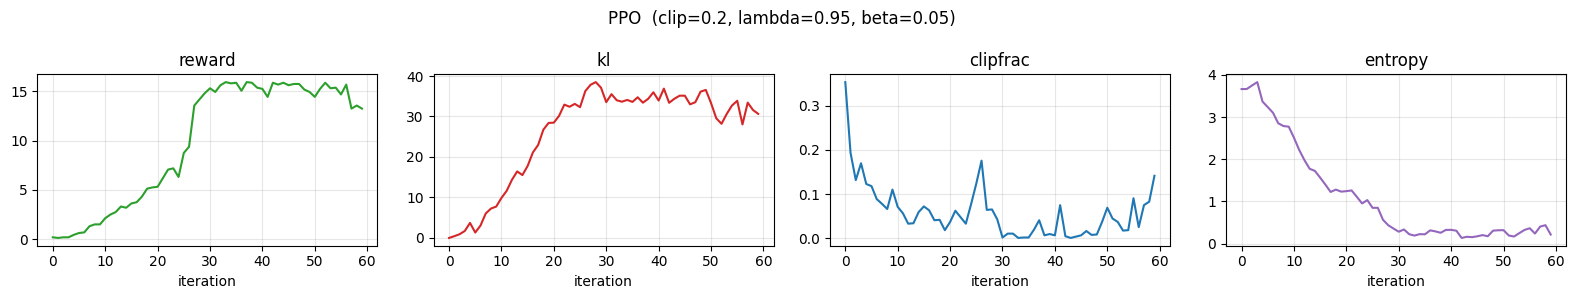

In [13]:
def plot_hist(H, title=""):
    fig, ax = plt.subplots(1, 4, figsize=(16, 3))
    for a,(k,c) in zip(ax, [("reward","tab:green"),("kl","tab:red"),
                            ("clipfrac","tab:blue"),("entropy","tab:purple")]):
        a.plot(H[k], color=c); a.set_title(k); a.set_xlabel("iteration"); a.grid(alpha=.3)
    fig.suptitle(title); plt.tight_layout(); plt.show()

plot_hist(H, f"PPO  (clip={cfg.clip_eps}, lambda={cfg.gae_lambda}, beta={cfg.kl_coef})")

## 11 · Before vs after — did behavior actually change?

In [14]:
@torch.no_grad()
def sample_some(n=4):
    saved = copy.deepcopy(policy.state_dict()); out = {}
    for label, state in [("BEFORE", policy_fresh_state), ("AFTER", saved)]:
        policy.load_state_dict(state)
        c = replace(cfg, batch_size=n)
        _, _, _, texts = rollout(c)
        out[label] = (texts, reward_fn(texts))
    policy.load_state_dict(saved)
    return out

for label,(texts,R) in sample_some().items():
    print(f"\n=== {label}  (mean reward {R.mean():.2f}) ===")
    for t,r in zip(texts, R): print(f"  [{r:.0f}] {cfg.prompt}{t}")


=== BEFORE  (mean reward 0.25) ===
  [0] I watched the movie last night and it looked weird. Cow Mangold was washing his hands doing the SHOTS act
  [1] I watched the movie last night and lost track. No

question I loved it and because this came out

  [0] I watched the movie last night and thought: Really, what a power act this to what our nation is. Because
  [0] I watched the movie last night and it was one of those absolute gems. I really missed it. I would go

=== AFTER  (mean reward 16.00) ===
  [16] I watched the movie last night and great great great great great great great great great great great great great great great great
  [16] I watched the movie last night and great great great great great great great great great great great great great great great great
  [16] I watched the movie last night and great great great great great great great great great great great great great great great great
  [16] I watched the movie last night and great great great great great great gr

## 12 · 🎯 Headline experiment: sweep $\beta$ → reward hacking / KL blow-up

Re-run training from the same fresh weights for several KL coefficients and overlay the curves. The story you'll see:

- **$\beta = 0$** (no leash): reward keeps climbing, **KL runs away**, completions degenerate into positive-word salad — *Goodhart's law*, the model games the reward.
- **moderate $\beta$**: reward improves while KL stays bounded — the regime you actually want.
- **large $\beta$**: the leash dominates, the policy barely moves, reward stays flat.

This is *why* RLHF keeps a reference model and a KL penalty — exactly the term in our PPO loss slide.


--- beta = 0.0 ---
it  0  reward  0.125  KL/seq   0.000  clipfrac 0.351  ent 3.610

--- beta = 0.05 ---
it  0  reward  0.000  KL/seq   0.000  clipfrac 0.388  ent 3.780

--- beta = 0.2 ---
it  0  reward  0.188  KL/seq   0.000  clipfrac 0.359  ent 3.689

--- beta = 1.0 ---
it  0  reward  0.188  KL/seq   0.000  clipfrac 0.362  ent 3.731


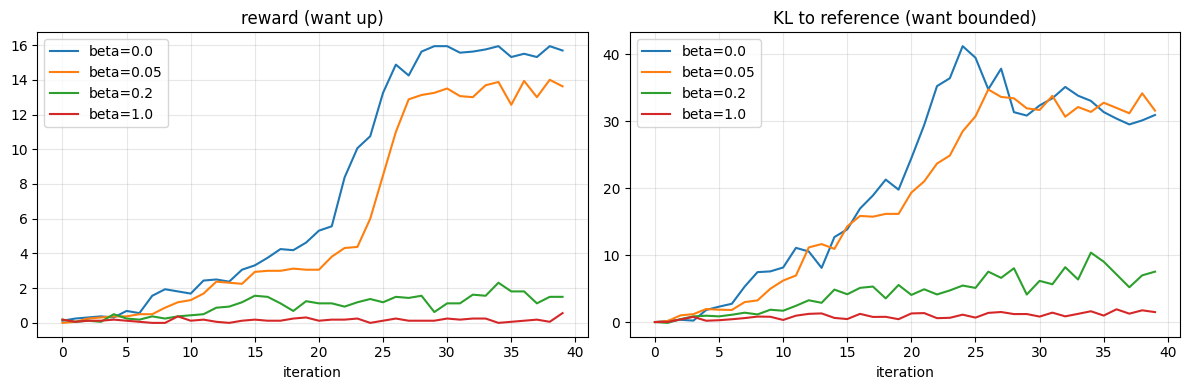

In [15]:
def run_sweep(betas, iters=40):
    runs = {}
    policy_states = {}
    for b in betas:
        policy.load_state_dict(copy.deepcopy(policy_fresh_state))
        c = replace(cfg, kl_coef=b, iters=iters)
        print(f"\n--- beta = {b} ---")
        runs[b] = train(c, log_every=iters)  # only final line
        policy_states[b] = copy.deepcopy(policy.state_dict())
    return runs, policy_states

sweep, sweep_states = run_sweep([0.0, 0.05, 0.2, 1.0])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for b, H in sweep.items():
    ax[0].plot(H["reward"], label=f"beta={b}")
    ax[1].plot(H["kl"], label=f"beta={b}")
ax[0].set_title("reward (want up)"); ax[1].set_title("KL to reference (want bounded)")
for a in ax: a.set_xlabel("iteration"); a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [16]:
# Per-token prediction breakdown for each beta after the sweep (mirrors cell 16)
saved_policy = copy.deepcopy(policy.state_dict())

for b, state in sweep_states.items():
    policy.load_state_dict(state)
    seq, L, T, texts = rollout(replace(cfg, batch_size=1))
    with torch.no_grad():
        old_lp, old_V, _ = aligned_logps_values(policy, seq, L, T, is_policy=True)
        ref_lp, _, _     = aligned_logps_values(ref,    seq, L, T, is_policy=False)
    kl_tok = old_lp - ref_lp
    R = reward_fn(texts)
    rew = build_rewards(R, kl_tok, b)
    adv, ret = compute_gae(rew, old_V, cfg.gamma, cfg.gae_lambda)

    print(f"\n=== beta = {b}  |  reward R = {R[0].item():.2f} ===")
    print("SAMPLE COMPLETION:", repr(cfg.prompt + texts[0]))
    resp_tokens = seq[0, L:L+T]
    hdr = f"{'token':>12}{'old_lp':>9}{'ref_lp':>9}{'kl':>8}{'V':>8}{'adv':>8}{'ret':>8}"
    print(hdr); print("-" * len(hdr))
    for t in range(min(T, 8)):
        tok = repr(tokenizer.decode(resp_tokens[t]))
        print(f"{tok:>12}{old_lp[0,t]:>9.3f}{ref_lp[0,t]:>9.3f}{kl_tok[0,t]:>8.3f}"
              f"{old_V[0,t]:>8.3f}{adv[0,t]:>8.3f}{ret[0,t]:>8.3f}")

policy.load_state_dict(saved_policy)


=== beta = 0.0  |  reward R = 16.00 ===
SAMPLE COMPLETION: 'I watched the movie last night and great love great great great great great great great great great great great great great great'
       token   old_lp   ref_lp      kl       V     adv     ret
--------------------------------------------------------------
    ' great'   -0.209  -10.482  10.273   5.089   5.210  10.299
     ' love'   -1.736   -6.323   4.587   5.324   5.237  10.561
    ' great'   -0.202  -10.758  10.556   5.277   5.562  10.839
    ' great'   -0.641   -7.107   6.467   5.378   5.749  11.126
    ' great'   -0.509   -4.348   3.839   5.389   6.039  11.428
    ' great'   -0.344   -1.148   0.804   5.395   6.351  11.746
    ' great'   -0.203   -0.646   0.443   5.398   6.682  12.080
    ' great'   -0.114   -0.444   0.331   5.399   7.032  12.432

=== beta = 0.05  |  reward R = 13.00 ===
SAMPLE COMPLETION: 'I watched the movie last night and really great great great great great great great great great greatgreat great gre

<All keys matched successfully>

## 13 · (Optional) live sliders

If `ipywidgets` renders in your environment (Colab/Jupyter), this gives tap-to-change dials. If it doesn't render, just edit the **config cell** and re-run training, or use the sweep above — same lesson, no widget dependency.

In [17]:
try:
    import ipywidgets as W
    from IPython.display import display
    def run(clip_eps, gae_lambda, kl_coef, lr_exp, iters):
        policy.load_state_dict(copy.deepcopy(policy_fresh_state))
        c = replace(cfg, clip_eps=clip_eps, gae_lambda=gae_lambda,
                         kl_coef=kl_coef, lr=10**lr_exp, iters=iters)
        plot_hist(train(c, log_every=iters), f"clip={clip_eps} lam={gae_lambda} beta={kl_coef}")
        _, _, _, texts = rollout(replace(c, batch_size=4))
        R = reward_fn(texts)
        print(f"\nSample completions after training  (mean reward {R.mean():.2f}):")
        for t, r in zip(texts, R):
            print(f"  [{r:.0f}] {cfg.prompt}{t}")
    W.interact_manual(run,
        clip_eps=W.FloatSlider(value=0.2, min=0.05, max=0.6, step=0.05),
        gae_lambda=W.FloatSlider(value=0.95, min=0.0, max=1.0, step=0.05),
        kl_coef=W.FloatSlider(value=0.05, min=0.0, max=1.0, step=0.05),
        lr_exp=W.FloatSlider(value=-4.7, min=-6, max=-4, step=0.1, description="log10(lr)"),
        iters=W.IntSlider(value=40, min=10, max=120, step=10))
except Exception as e:
    print("ipywidgets not available — use the config cell + sweep instead.", e)

interactive(children=(FloatSlider(value=0.2, description='clip_eps', max=0.6, min=0.05, step=0.05), FloatSlide…

## 14 · Student exercises (predict → turn the dial → verify)

1. **Clip $\epsilon$.** Set `clip_eps` to 0.05 and to 0.6. Predict the effect on `clipfrac` and on stability *before* running. Which gives faster but riskier learning?
2. **GAE $\lambda$.** Compare $\lambda=0$ (high-bias, one-step TD) vs $\lambda=1$ (high-variance, Monte-Carlo). Watch the noise in the reward curve.
3. **$\beta$ vs reward scale.** Switch `reward_fn` to the `!`-counting version (much larger magnitude). What happens to the good $\beta$ range? (Lesson: the KL coefficient is *scale-dependent* — same point as DPO's $\beta$.)
4. **PPO epochs.** Push `ppo_epochs` to 8. Why does `clipfrac` rise? When does data reuse start to hurt?
5. **Kill the critic.** Replace advantages with `returns - returns.mean()` (no value head). What did GAE buy you?

### Dial → effect cheat-sheet
| Dial | Too low | Too high |
|---|---|---|
| clip $\epsilon$ | over-cautious, slow | big risky steps, instability |
| GAE $\lambda$ | biased advantages | noisy, high-variance updates |
| KL $\beta$ | **reward hacking, KL blow-up** | policy frozen, no learning |

## 14 · Homework submission notes

Run each experiment below in Colab. Keep the printed output and plot visible in the submitted notebook.

### Exercise 1 — Clip $\epsilon$

**Prediction (before running):** With `clip_eps=0.05`, PPO is allowed to make only very small policy changes, so learning should be more cautious and clipping should happen more often. With `clip_eps=0.6`, PPO permits much larger changes, so it can learn faster but is more likely to be unstable.

**Results:** For `clip_eps=0.05`, the final five-iteration averages were reward `0.800`, KL/sequence `5.640`, and `clipfrac=0.446`. For `clip_eps=0.6`, they were reward `12.300`, KL/sequence `32.666`, and `clipfrac=0.002`.

**Conclusion:** The tight clip threshold clipped many updates and kept KL relatively low, but learning was slow. The large threshold barely clipped at all and achieved much higher reward, but with much larger KL drift. Therefore, `0.6` gave faster but riskier learning.


================== clip_eps = 0.05 ==================
it  0  reward  0.000  KL/seq   0.000  clipfrac 0.654  ent 3.755
it 10  reward  0.125  KL/seq   0.901  clipfrac 0.459  ent 3.679
it 20  reward  0.125  KL/seq   1.418  clipfrac 0.434  ent 4.074


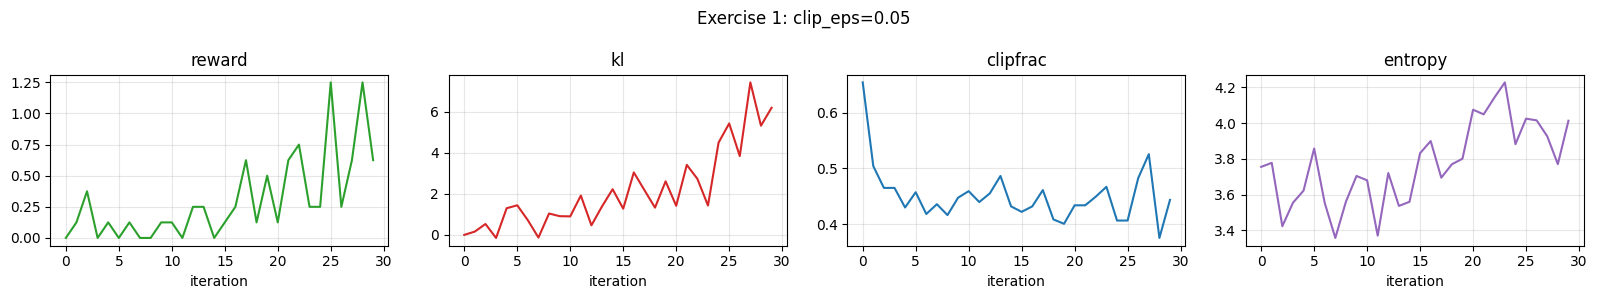

Final 5-iteration averages: reward=0.800, KL/seq=5.640, clipfrac=0.446

================== clip_eps = 0.6 ==================
it  0  reward  0.000  KL/seq   0.000  clipfrac 0.213  ent 3.808
it 10  reward  1.000  KL/seq   3.604  clipfrac 0.031  ent 2.430
it 20  reward  3.500  KL/seq  23.413  clipfrac 0.004  ent 1.346


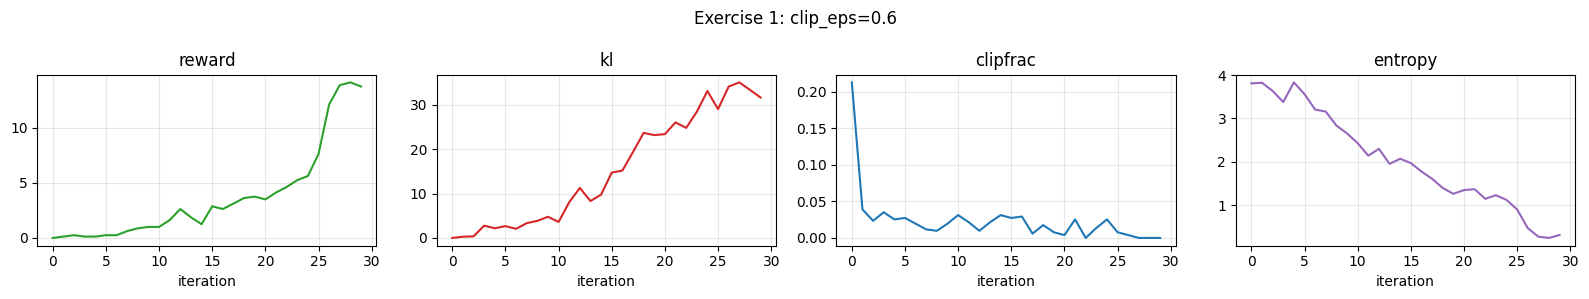

Final 5-iteration averages: reward=12.300, KL/seq=32.666, clipfrac=0.002


<All keys matched successfully>

In [18]:
# Exercise 1: PPO clipping comparison
# The policy is reset before each run, so clip_eps is the only intended difference.
clip_results = {}
for clip_eps in (0.05, 0.6):
    print(f"\n{'=' * 18} clip_eps = {clip_eps} {'=' * 18}")
    torch.manual_seed(0)
    policy.load_state_dict(copy.deepcopy(policy_fresh_state))
    clip_cfg = replace(cfg, clip_eps=clip_eps, batch_size=8, iters=30)
    clip_results[clip_eps] = train(clip_cfg, log_every=10)
    plot_hist(clip_results[clip_eps], f"Exercise 1: clip_eps={clip_eps}")
    print(
        "Final 5-iteration averages: "
        f"reward={sum(clip_results[clip_eps]['reward'][-5:]) / 5:.3f}, "
        f"KL/seq={sum(clip_results[clip_eps]['kl'][-5:]) / 5:.3f}, "
        f"clipfrac={sum(clip_results[clip_eps]['clipfrac'][-5:]) / 5:.3f}"
    )

# Leave the notebook's policy in its original state for later exercises.
policy.load_state_dict(copy.deepcopy(policy_fresh_state))

### Exercise 2 — GAE $\lambda$

**Prediction (before running):** `gae_lambda=0` uses only one-step TD errors. This should be more biased but less variable. `gae_lambda=1` uses the full sampled return, so it should have less bias but a noisier reward curve because it uses more Monte-Carlo information.

**Results:** With `gae_lambda=0`, final reward was `0.250`, reward-curve standard deviation was `0.137`, and final KL/sequence was `1.752`. With `gae_lambda=1`, these values were `3.750`, `1.459`, and `20.466`.

**Conclusion:** The `lambda=1` reward curve was much noisier (standard deviation `1.459` versus `0.137`), which matches the high-variance Monte-Carlo prediction. It nevertheless achieved higher reward in this run. `lambda=0` was smoother but learned much more slowly, illustrating its bias/variance trade-off.


================== gae_lambda = 0.0 ==================
it  0  reward  0.000  KL/seq   0.000  clipfrac 0.428  ent 3.669
it 10  reward  0.000  KL/seq   1.401  clipfrac 0.158  ent 3.719
it 20  reward  0.000  KL/seq   0.575  clipfrac 0.111  ent 3.842


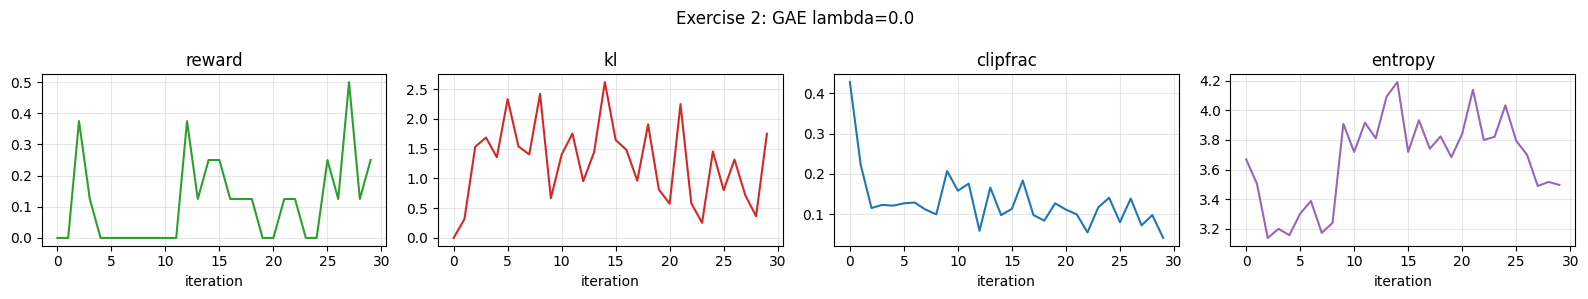

Summary: final reward=0.250, reward-curve std=0.137, final KL/seq=1.752

================== gae_lambda = 1.0 ==================
it  0  reward  0.000  KL/seq   0.000  clipfrac 0.482  ent 3.748
it 10  reward  0.125  KL/seq   3.300  clipfrac 0.109  ent 3.821
it 20  reward  1.875  KL/seq  12.329  clipfrac 0.094  ent 2.069


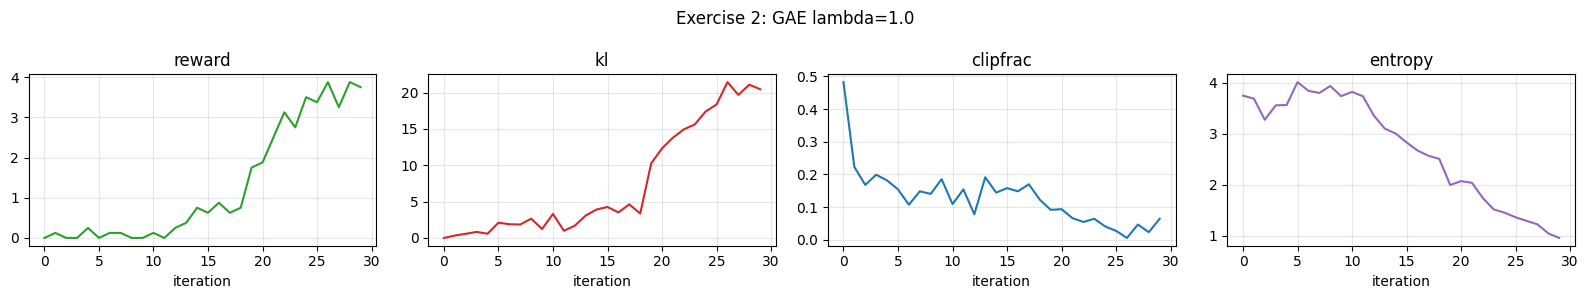

Summary: final reward=3.750, reward-curve std=1.459, final KL/seq=20.466


<All keys matched successfully>

In [19]:
# Exercise 2: compare the two endpoints of the GAE lambda dial.
# The policy is reset before each run, so gae_lambda is the only intended difference.
gae_results = {}
for gae_lambda in (0.0, 1.0):
    print(f"\n{'=' * 18} gae_lambda = {gae_lambda} {'=' * 18}")
    torch.manual_seed(0)
    policy.load_state_dict(copy.deepcopy(policy_fresh_state))
    gae_cfg = replace(cfg, gae_lambda=gae_lambda, batch_size=8, iters=30)
    gae_results[gae_lambda] = train(gae_cfg, log_every=10)
    plot_hist(gae_results[gae_lambda], f"Exercise 2: GAE lambda={gae_lambda}")
    reward_std = torch.tensor(gae_results[gae_lambda]["reward"]).std().item()
    print(
        "Summary: "
        f"final reward={gae_results[gae_lambda]['reward'][-1]:.3f}, "
        f"reward-curve std={reward_std:.3f}, "
        f"final KL/seq={gae_results[gae_lambda]['kl'][-1]:.3f}"
    )

policy.load_state_dict(copy.deepcopy(policy_fresh_state))

### Exercise 3 — KL $\beta$ and reward scale

**Prediction (before running):** Counting `!` changes the reward scale, so the old KL coefficient (`0.05`) should no longer be assumed appropriate. A larger-magnitude reward needs a larger `beta` to keep the KL penalty comparable; otherwise the policy can chase punctuation reward and drift far from the reference.

**Results:** With `beta=0.05`, final five-iteration averages were reward `1.875` and KL/sequence `10.435`. Raising beta to `0.2` reduced them to `0.050` and `1.422`; `beta=0.5` reduced them further to `0.025` and `1.242`.

**Conclusion:** The low beta allowed the policy to optimize the `!` reward but caused much larger KL drift. Increasing beta strongly constrained the drift but nearly stopped reward learning. Therefore, the useful beta range depends on reward scale: this altered reward needs a beta larger than `0.05`, but a value between `0.05` and `0.2` would be the sensible range to tune further rather than jumping directly to `0.5`.


================== bang reward, beta = 0.05 ==================
it  0  reward  0.000  KL/seq   0.000  clipfrac 0.459  ent 3.775
it 10  reward  0.125  KL/seq   1.318  clipfrac 0.123  ent 3.473
it 20  reward  1.125  KL/seq   4.829  clipfrac 0.127  ent 3.933


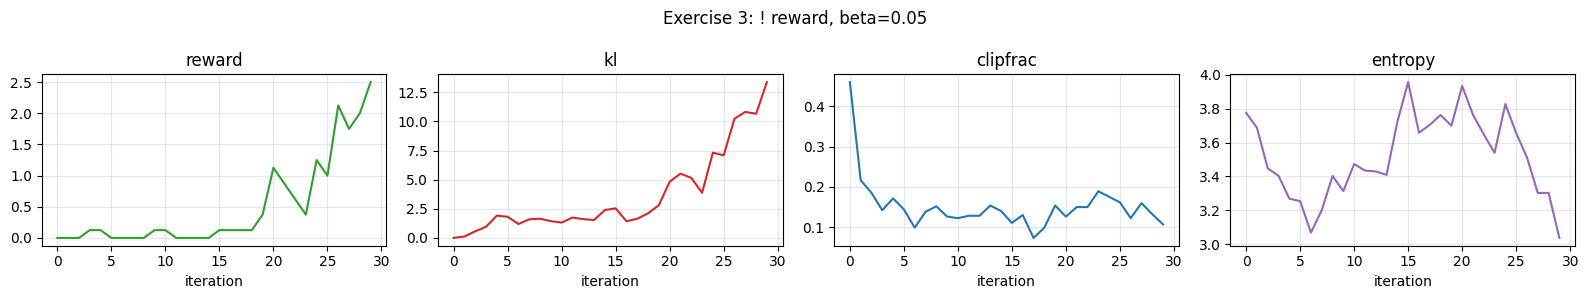

Final 5-iteration averages: reward=1.875, KL/seq=10.435

================== bang reward, beta = 0.2 ==================
it  0  reward  0.000  KL/seq   0.000  clipfrac 0.459  ent 3.775
it 10  reward  0.125  KL/seq   1.074  clipfrac 0.129  ent 3.701
it 20  reward  0.000  KL/seq   1.230  clipfrac 0.133  ent 3.562


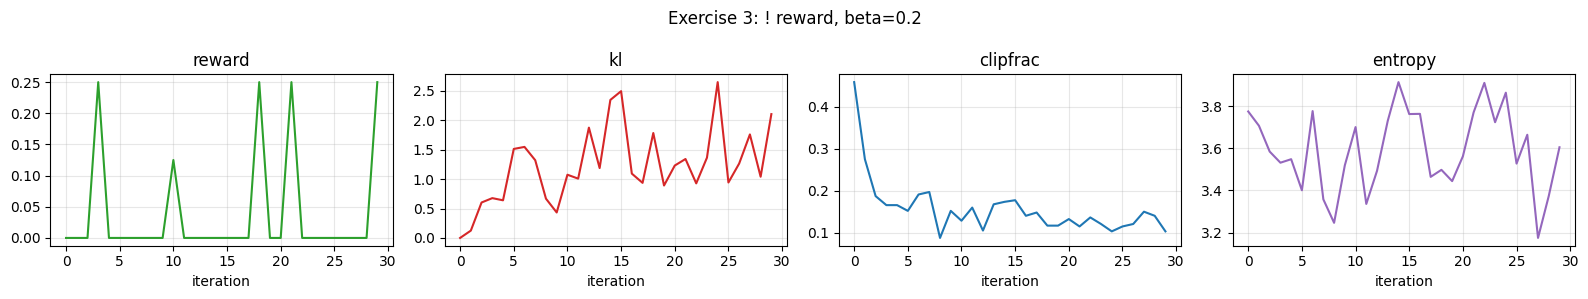

Final 5-iteration averages: reward=0.050, KL/seq=1.422

================== bang reward, beta = 0.5 ==================
it  0  reward  0.000  KL/seq   0.000  clipfrac 0.459  ent 3.775
it 10  reward  0.000  KL/seq   0.313  clipfrac 0.188  ent 3.636
it 20  reward  0.000  KL/seq   0.898  clipfrac 0.104  ent 3.851


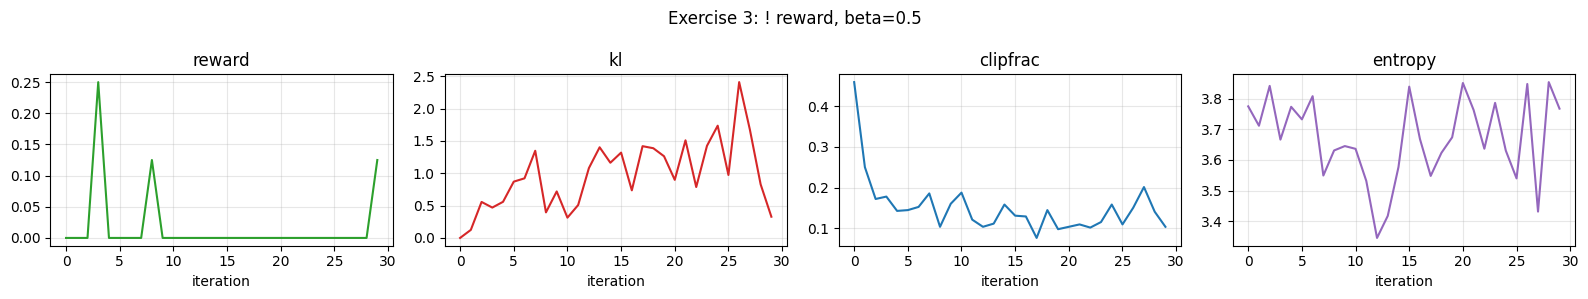

Final 5-iteration averages: reward=0.025, KL/seq=1.242


In [20]:
# Exercise 3: the same PPO setup, but reward is the number of exclamation marks.
# Compare several beta values because beta must scale with the reward magnitude.
def bang_reward_fn(texts):
    return torch.tensor([float(t.count("!")) for t in texts], device=device)

original_reward_fn = reward_fn
reward_fn = bang_reward_fn
bang_results = {}
try:
    for kl_coef in (0.05, 0.2, 0.5):
        print(f"\n{'=' * 18} bang reward, beta = {kl_coef} {'=' * 18}")
        torch.manual_seed(0)
        policy.load_state_dict(copy.deepcopy(policy_fresh_state))
        bang_cfg = replace(cfg, kl_coef=kl_coef, batch_size=8, iters=30)
        bang_results[kl_coef] = train(bang_cfg, log_every=10)
        plot_hist(bang_results[kl_coef], f"Exercise 3: ! reward, beta={kl_coef}")
        print(
            "Final 5-iteration averages: "
            f"reward={sum(bang_results[kl_coef]['reward'][-5:]) / 5:.3f}, "
            f"KL/seq={sum(bang_results[kl_coef]['kl'][-5:]) / 5:.3f}"
        )
finally:
    reward_fn = original_reward_fn
    policy.load_state_dict(copy.deepcopy(policy_fresh_state))

### Exercise 4 — PPO epochs

**Prediction (before running):** More PPO epochs reuse the same rollout more times. As the policy is repeatedly updated, its new log-probabilities move farther from the fixed old log-probabilities, so the importance ratio moves farther from 1 and `clipfrac` should rise. Too much reuse can overfit one rollout and make the update less reliable.

**Results:** With the normal `ppo_epochs=4`, final five-iteration averages were reward `3.350`, KL/sequence `17.527`, and `clipfrac=0.086`. With `ppo_epochs=8`, they were reward `5.400`, KL/sequence `37.245`, and `clipfrac=0.126`.

**Conclusion:** Reusing each rollout for eight epochs increased `clipfrac` and more than doubled KL drift. It also increased short-run reward here, but the much larger policy change shows why excessive reuse can hurt: the policy becomes increasingly off-policy relative to the rollout data, so the update is less trustworthy.


================== ppo_epochs = 4 ==================
it  0  reward  0.000  KL/seq   0.000  clipfrac 0.459  ent 3.775
it 10  reward  0.250  KL/seq   1.732  clipfrac 0.188  ent 2.970
it 20  reward  2.000  KL/seq  10.290  clipfrac 0.123  ent 2.458


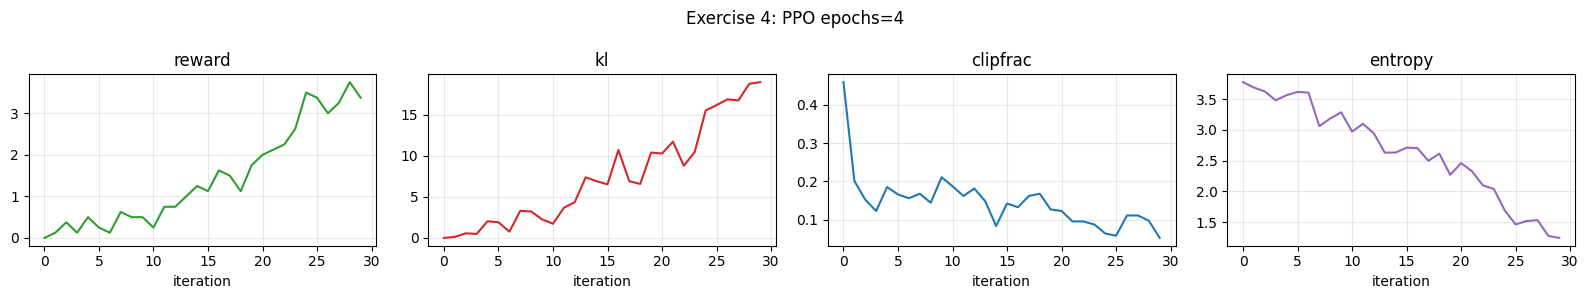

Final 5-iteration averages: reward=3.350, KL/seq=17.527, clipfrac=0.086

================== ppo_epochs = 8 ==================
it  0  reward  0.000  KL/seq   0.000  clipfrac 0.679  ent 3.643
it 10  reward  1.000  KL/seq   9.864  clipfrac 0.397  ent 2.455
it 20  reward  2.375  KL/seq  27.586  clipfrac 0.376  ent 1.463


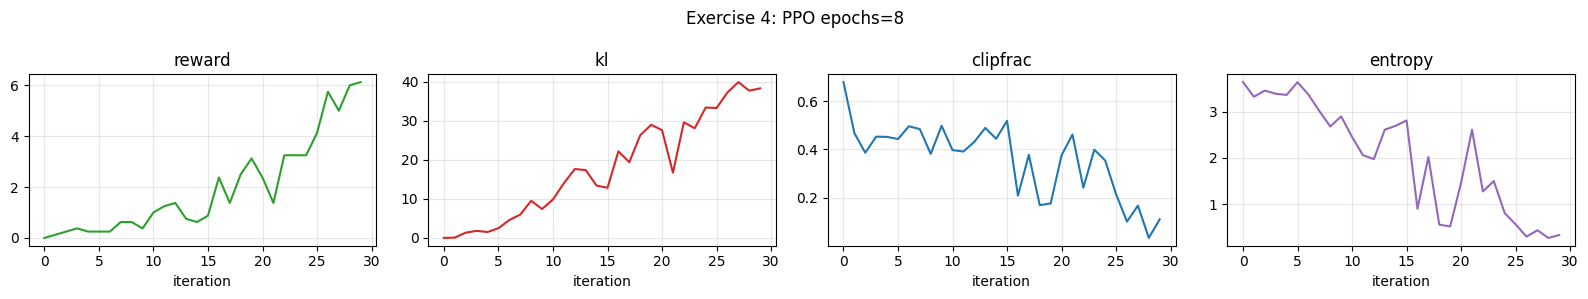

Final 5-iteration averages: reward=5.400, KL/seq=37.245, clipfrac=0.126


<All keys matched successfully>

In [21]:
# Exercise 4: compare normal rollout reuse with the requested 8 PPO epochs.
epoch_results = {}
for ppo_epochs in (4, 8):
    print(f"\n{'=' * 18} ppo_epochs = {ppo_epochs} {'=' * 18}")
    torch.manual_seed(0)
    policy.load_state_dict(copy.deepcopy(policy_fresh_state))
    epoch_cfg = replace(cfg, ppo_epochs=ppo_epochs, batch_size=8, iters=30)
    epoch_results[ppo_epochs] = train(epoch_cfg, log_every=10)
    plot_hist(epoch_results[ppo_epochs], f"Exercise 4: PPO epochs={ppo_epochs}")
    print(
        "Final 5-iteration averages: "
        f"reward={sum(epoch_results[ppo_epochs]['reward'][-5:]) / 5:.3f}, "
        f"KL/seq={sum(epoch_results[ppo_epochs]['kl'][-5:]) / 5:.3f}, "
        f"clipfrac={sum(epoch_results[ppo_epochs]['clipfrac'][-5:]) / 5:.3f}"
    )

policy.load_state_dict(copy.deepcopy(policy_fresh_state))

### Exercise 5 — Kill the critic

**Prediction (before running):** Without the critic, we use a Monte-Carlo reward-to-go return and subtract only its batch mean. This is a valid policy-gradient baseline, but it does not estimate which states are already promising. I expect reward to be noisier and learning to be less sample-efficient than GAE with a learned value baseline.

**Results:** GAE with the critic produced final five-iteration averages of reward `3.350`, KL/sequence `17.527`, and `clipfrac=0.086`. The no-critic run produced reward `5.175`, KL/sequence `27.432`, and `clipfrac=0.139`.

**Conclusion:** In this short run, the critic-free method reached higher reward, so the prediction was not fully supported by reward alone. However, it also had higher KL drift and more clipping, evidence of a less controlled update. GAE gives PPO a learned, state-dependent baseline instead of one global mean; this normally reduces variance and makes learning more stable and sample-efficient, even though one small stochastic run can favor the no-critic version.


================== GAE + critic ==================
it  0  reward  0.000  KL/seq   0.000  clipfrac 0.459  ent 3.775
it 10  reward  0.250  KL/seq   1.732  clipfrac 0.188  ent 2.970
it 20  reward  2.000  KL/seq  10.290  clipfrac 0.123  ent 2.458


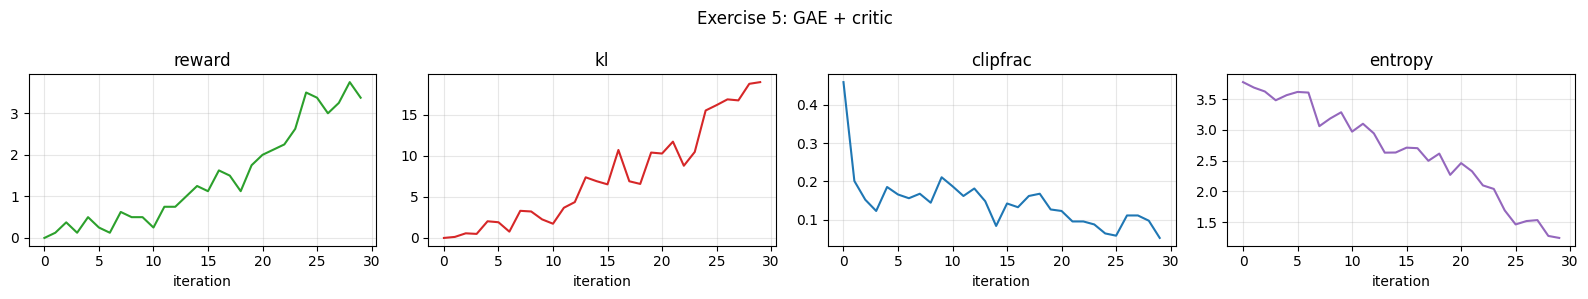

Final 5-iteration averages: reward=3.350, KL/seq=17.527, clipfrac=0.086

================== no critic ==================
it  0  reward  0.000  KL/seq   0.000  clipfrac 0.000
it 10  reward  0.750  KL/seq   3.094  clipfrac 0.207
it 20  reward  3.250  KL/seq  20.524  clipfrac 0.221


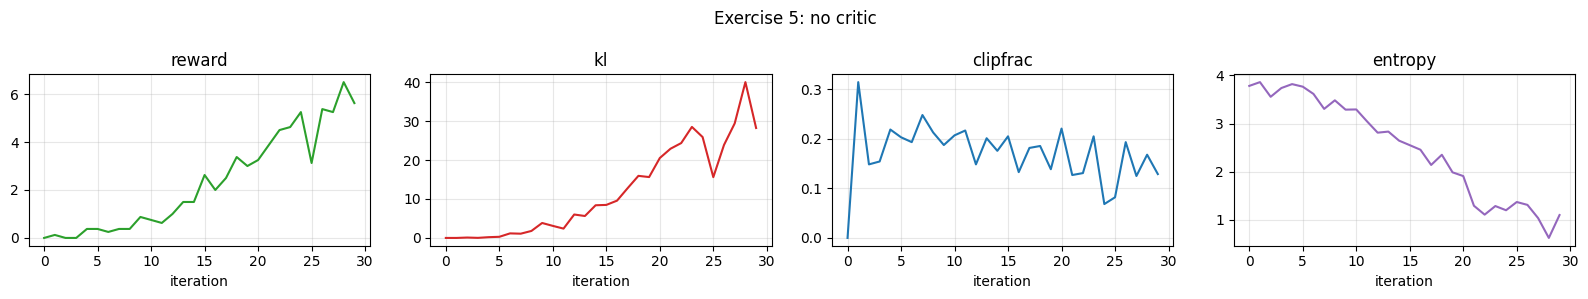

Final 5-iteration averages: reward=5.175, KL/seq=27.432, clipfrac=0.139


<All keys matched successfully>

In [22]:
# Exercise 5: a PPO update with no critic loss and centered Monte-Carlo returns.
# This implements the requested advantage: returns - returns.mean().
def monte_carlo_returns(rewards, gamma):
    returns = torch.zeros_like(rewards)
    running = torch.zeros(rewards.shape[0], device=rewards.device)
    for t in reversed(range(rewards.shape[1])):
        running = rewards[:, t] + gamma * running
        returns[:, t] = running
    return returns


def ppo_update_no_critic(seq, L, T, old_lp, advantages, cfg, opt):
    stats = {"clipfrac": [], "pg": [], "ent": []}
    for _ in range(cfg.ppo_epochs):
        new_lp, _, ent = aligned_logps_values(policy, seq, L, T, is_policy=True)
        ratio = torch.exp(new_lp - old_lp)
        clipped_ratio = torch.clamp(ratio, 1 - cfg.clip_eps, 1 + cfg.clip_eps)
        pg = -torch.min(ratio * advantages, clipped_ratio * advantages).mean()
        loss = pg - cfg.ent_coef * ent.mean()
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(policy.parameters(), 1.0); opt.step()
        stats["clipfrac"].append(((ratio - 1).abs() > cfg.clip_eps).float().mean().item())
        stats["pg"].append(pg.item()); stats["ent"].append(ent.mean().item())
    return {key: sum(values) / len(values) for key, values in stats.items()}


def train_no_critic(cfg, log_every=10):
    opt = torch.optim.Adam(policy.parameters(), lr=cfg.lr)
    history = {"reward": [], "kl": [], "clipfrac": [], "entropy": []}
    for iteration in range(cfg.iters):
        seq, L, T, texts = rollout(cfg)
        with torch.no_grad():
            old_lp, _, _ = aligned_logps_values(policy, seq, L, T, is_policy=True)
            ref_lp, _, _ = aligned_logps_values(ref, seq, L, T, is_policy=False)
        kl_tok = old_lp - ref_lp
        rewards = build_rewards(reward_fn(texts), kl_tok, cfg.kl_coef)
        returns = monte_carlo_returns(rewards, cfg.gamma)
        advantages = returns - returns.mean()
        stats = ppo_update_no_critic(seq, L, T, old_lp, advantages, cfg, opt)
        history["reward"].append(reward_fn(texts).mean().item())
        history["kl"].append(kl_tok.sum(-1).mean().item())
        history["clipfrac"].append(stats["clipfrac"]); history["entropy"].append(stats["ent"])
        if iteration % log_every == 0:
            print(f"it{iteration:3d}  reward {history['reward'][-1]:6.3f}  "
                  f"KL/seq {history['kl'][-1]:7.3f}  clipfrac {stats['clipfrac']:.3f}")
    return history

# Compare the original GAE+critic PPO loop with the no-critic loop.
critic_results = {}
for label, trainer in (("GAE + critic", train), ("no critic", train_no_critic)):
    print(f"\n{'=' * 18} {label} {'=' * 18}")
    torch.manual_seed(0)
    policy.load_state_dict(copy.deepcopy(policy_fresh_state))
    critic_cfg = replace(cfg, batch_size=8, iters=30)
    critic_results[label] = trainer(critic_cfg, log_every=10)
    plot_hist(critic_results[label], f"Exercise 5: {label}")
    print(
        "Final 5-iteration averages: "
        f"reward={sum(critic_results[label]['reward'][-5:]) / 5:.3f}, "
        f"KL/seq={sum(critic_results[label]['kl'][-5:]) / 5:.3f}, "
        f"clipfrac={sum(critic_results[label]['clipfrac'][-5:]) / 5:.3f}"
    )

policy.load_state_dict(copy.deepcopy(policy_fresh_state))